In [1]:
import json
import string

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator
from scipy.interpolate import interp1d


In [2]:
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

snap = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])
pub_snaps = np.array(pub_data["index"])
pub_tims = np.array(pub_data["time_Gyr"])

all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)


(0.1, 5.0)

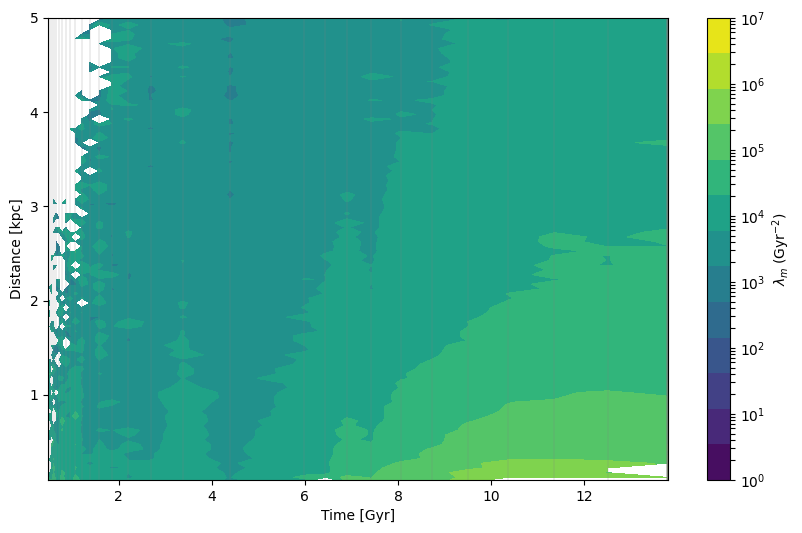

In [11]:
# ============================================================
# Settings
# ============================================================

sim = "m12m"
situ_flag = None  # True = in-situ, False = ex-situ, None = both
inmw = True  # True = only MW GCs, False = all alive GCs
interp = False  # True = Radially interpolate at snapshots, False = Do not

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

n_snaps = 39
n_rbins = 100
rmax = 5

# ============================================================
# Radial binning
# ============================================================

r_bins = np.linspace(0, rmax, n_rbins + 1)
r_centres = 0.5 * (r_bins[:-1] + r_bins[1:])

# ============================================================
# Accumulators
# ============================================================

tm_sum_in = np.zeros((n_snaps, n_rbins))
tm_count_in = np.zeros((n_snaps, n_rbins))

# ============================================================
# Loop over ghosts and snapshots
# ============================================================

for it_id in ghost_data.keys():
    snap_group = ghost_data[it_id]["snapshots"]

    for i, snp_id in enumerate(snap_group.keys()):
        snp_dat = snap_group[snp_id]

        grp = snp_dat["grpid"][()]
        nacc = snp_dat["nacc_flag"][()]

        if situ_flag is None:
            grp_msk = np.ones(len(grp), dtype=bool)
        elif situ_flag:
            grp_msk = grp == 0
        else:
            grp_msk = grp != 0

        if inmw:
            mw_msk = nacc.astype(bool)
        else:
            mw_msk = np.ones(len(grp), dtype=bool)

        msk = grp_msk & mw_msk

        teigs = snp_dat["tideig"][msk]
        rs = snp_dat["host.pos.sph"][:, 0][msk]

        for j in range(n_rbins):
            r_msk = (rs >= r_bins[j]) & (rs < r_bins[j + 1])
            if np.any(r_msk):
                tm_sum_in[i, j] += np.mean(teigs[r_msk])
                tm_count_in[i, j] += 1

# ============================================================
# Compute averages (NaN where empty)
# ============================================================

tm_avg_in = np.full_like(tm_sum_in, np.nan)
valid = tm_count_in > 0
tm_avg_in[valid] = tm_sum_in[valid] / tm_count_in[valid]

# ============================================================
# Prepare grid for contourf with boundary extension
# ============================================================

x = pub_tims  # (n_snaps,)
z_mid = tm_avg_in.T  # (n_rbins, n_snaps)

# Extend radius to include boundaries
y = np.concatenate(([0.0], r_centres, [rmax]))  # (n_rbins + 2,)

z = np.vstack([z_mid[0], z_mid, z_mid[-1]])  # (n_rbins + 2, n_snaps)

# ============================================================
# Radial interpolation to remove white gaps
# ============================================================

z_interp = z.copy()

if interp:
    for i in range(z.shape[1]):  # loop over snapshots
        col = z[:, i]
        m = np.isfinite(col)

        if m.sum() >= 2:
            f = interp1d(
                y[m],
                col[m],
                kind="linear",
                bounds_error=False,
                fill_value=(col[m][0], col[m][-1]),
            )
            z_interp[:, i] = f(y)

z_interp = np.clip(z_interp, 1, None)

# ============================================================
# Plot
# ============================================================

fig = plt.figure(figsize=(10, 6))

vmin, vmax = 1, 1e7
levels = np.logspace(np.log10(vmin), np.log10(vmax), 14)

contour = plt.contourf(
    x,
    y,
    z_interp,
    levels=levels,
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)

cbar = plt.colorbar(contour, label=r"$\lambda_m\;(\mathrm{Gyr}^{-2})$")
cbar.locator = LogLocator(base=10.0, subs="all", numticks=12)
cbar.update_ticks()

plt.xlabel("Time [Gyr]")
plt.ylabel("Distance [kpc]")

for t in x:
    plt.plot([t, t], [0, rmax], color="grey", lw=0.2)

plt.xlim(x.min(), x.max())
plt.ylim(0.1, rmax)

# plt.yscale("log")

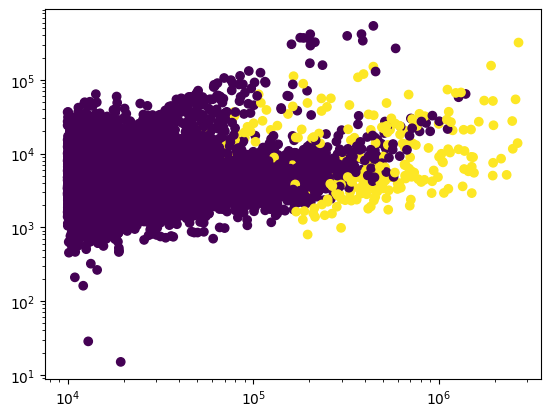

In [12]:
sim = "m12c"
it_id = "it001"


ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

src_dat = ghost_data[it_id]["source"]
teig = src_dat["tideig.avg"][()]
mfor = 10 ** src_dat["logm_tfor"][()]
sflg = src_dat["s_flag"][()]

plt.scatter(mfor, teig, c=sflg)
plt.xscale("log")
plt.yscale("log")

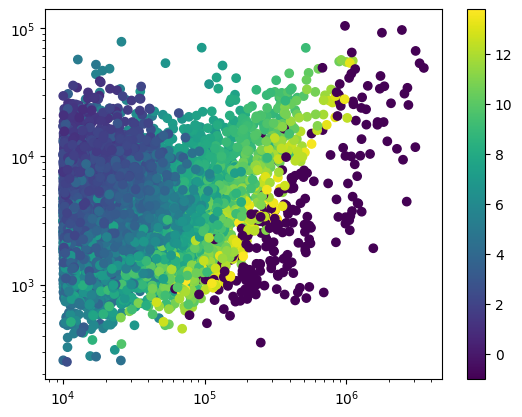

In [103]:
src_dat = ghost_data[it_id]["source"]
teig = src_dat["tideig.avg"][()]
mfor = 10 ** src_dat["logm_tfor"][()]
tdis = src_dat["tdis"][()]

plt.scatter(mfor, teig, c=tdis)
plt.colorbar()
plt.xscale("log")
plt.yscale("log")

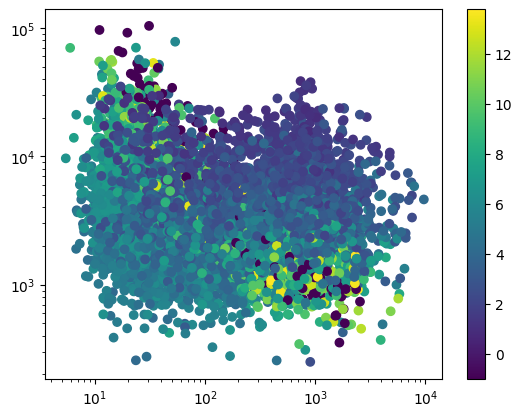

In [105]:
src_dat = ghost_data[it_id]["source"]
teig = src_dat["tideig.avg"][()]
pz0 = src_dat["torb_600"][()]
tdis = src_dat["tdis"][()]

plt.scatter(pz0, teig, c=tdis)
plt.colorbar()
plt.xscale("log")
plt.yscale("log")